# Chunk-Level XGBoost — Crossed Random Effects (Worker + Task)

Extends `random_intercept_chunk_level_oe.ipynb` by adding a **task-level random effect**
alongside the worker-level random effect.

**Model:** `y_ij = mu + b_j (worker) + a_i (task) + e_ij`

**Why add task effects?**
The worker-only model estimates `b_j` after controlling for measured task features
(Weight, Cube, Quantity etc.). But those features may not fully explain task difficulty.
If a worker consistently gets harder products, their `b_j` absorbs that task difficulty
and looks artificially high — they appear slower than they actually are.
Adding `a_i` (task random effect on ProductID) pulls out unmeasured product-specific
difficulty, leaving `b_j` as a cleaner estimate of true worker speed.

**Why ProductID?**
LocationID is already well-captured by Aisle_group and Level_group fixed effects.
ProductID captures residual product difficulty that Weight, Cube, and Quantity
don't fully explain. Partial pooling handles sparse products automatically.

**Sequential estimation (no pymer4/R required):**
statsmodels MixedLM only supports one grouping factor. We approximate the crossed
model sequentially:
1. Fit worker random intercepts on raw pick times → `worker_effect`
2. Subtract worker effects to get worker-adjusted residuals
3. Fit product random intercepts on those residuals → `task_effect`

**Four scenarios compared:**
1. `Baseline` — no worker or task features
2. `+ Worker` — worker random intercept only (your current model)
3. `+ Task` — task random intercept only
4. `+ Worker + Task` — both crossed random intercepts

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("/Users/betsyfrdmn/Lucas_Systems_Capstone_Project/data/processed")
WAREHOUSE    = "OF"
WORKCODES    = ["10", "20", "30"]
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026

NOT_AVAILABLE_AT_PREDICTION = [
    "Travel_Distance", "log_travel_distance",
    "same_aisle", "same_lockey", "diff_level", "same_location",
    "time_of_day", "day_of_week", "hour", "Hour",
]

## Helper Functions
Identical to `random_intercept_chunk_level_oe.ipynb` so results are directly comparable.

In [9]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=str(workcode)
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    distance_num = ["Travel_Distance", "log_travel_distance"]
    distance_cat = ["same_aisle", "same_location", "diff_level"]
    features = [f for f in features_all if f not in NOT_AVAILABLE_AT_PREDICTION]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE_AT_PREDICTION]
    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days  = sorted(df["date"].dropna().unique())
    n_test    = max(1, int(round(len(all_days) * test_ratio)))
    test_days = all_days[-n_test:]
    train_df  = df[df["date"] < test_days[0]].copy()
    test_df   = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def make_test_blocks(test_df, block_size=50):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks = []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.reset_index()
        for start in range(0, len(g) - block_size + 1, block_size):
            chunk = g.iloc[start:start + block_size]
            if len(chunk) == block_size:
                blocks.append({
                    "BlockID": f"{uid}_{day}_{start // block_size}",
                    "UserID":  uid,
                    "date":    day,
                    "indices": chunk["index"].tolist()
                })
    return blocks


def eval_blocks(blocks, actual_series, pred_series):
    actual_blocks = [actual_series.loc[b["indices"]].sum() for b in blocks]
    pred_blocks   = [pred_series.loc[b["indices"]].sum()   for b in blocks]
    mae = mean_absolute_error(actual_blocks, pred_blocks)
    r2  = r2_score(actual_blocks, pred_blocks)
    return mae, r2, actual_blocks, pred_blocks

## Step 1: Sequential Crossed Random Effects Estimation

**Step 1a:** `Time_Delta_sec ~ 1 + (1|UserID)` → `worker_effect` b_j  
**Step 1b:** worker-adjusted residuals = `Time_Delta_sec - worker_effect`  
**Step 1c:** `residual ~ 1 + (1|ProductID)` → `task_effect` a_i  

Both estimated on training data only — no leakage.  
Unseen workers or products at test time get effect = 0 (grand mean fallback).

In [10]:
def estimate_crossed_effects(train_df, max_iter=10, tol=0.01):
    """
    Iterative alternating estimation of crossed random intercepts.
    Approximates joint REML by alternating between worker and task fits
    until effects converge. Much closer to lme4 than a single-pass sequential fit.

    Returns:
      worker_effects : DataFrame [UserID, worker_effect]
      task_effects   : DataFrame [ProductID, task_effect]
    """
    df_re = train_df[["UserID", "ProductID", "Time_Delta_sec"]].dropna().copy()
    df_re["UserID"]    = df_re["UserID"].astype(str)
    df_re["ProductID"] = df_re["ProductID"].astype(str)

    n_workers  = df_re["UserID"].nunique()
    n_products = df_re["ProductID"].nunique()
    print(f"  Workers: {n_workers} | Unique products: {n_products}")

    # Initialize both effects to zero
    worker_map = {uid: 0.0 for uid in df_re["UserID"].unique()}
    task_map   = {pid: 0.0 for pid in df_re["ProductID"].unique()}

    for iteration in range(max_iter):
        old_worker_map = worker_map.copy()
        old_task_map   = task_map.copy()

        # --- Worker step ---
        # Subtract current task effects, fit worker intercepts on residual
        df_re["task_effect_cur"] = df_re["ProductID"].map(task_map).fillna(0.0)
        df_re["resid_for_worker"] = df_re["Time_Delta_sec"] - df_re["task_effect_cur"]

        worker_result = smf.mixedlm(
            "resid_for_worker ~ 1", data=df_re, groups=df_re["UserID"]
        ).fit(reml=True, disp=False)

        worker_map = {
            uid: float(v.iloc[0])
            for uid, v in worker_result.random_effects.items()
        }

        # --- Task step ---
        # Subtract current worker effects, fit product intercepts on residual
        df_re["worker_effect_cur"] = df_re["UserID"].map(worker_map).fillna(0.0)
        df_re["resid_for_task"] = df_re["Time_Delta_sec"] - df_re["worker_effect_cur"]

        try:
            task_result = smf.mixedlm(
                "resid_for_task ~ 1", data=df_re, groups=df_re["ProductID"]
            ).fit(reml=True, disp=False)

            task_map = {
                pid: float(v.iloc[0])
                for pid, v in task_result.random_effects.items()
            }
        except Exception as e:
            print(f"  [Task] Failed at iteration {iteration} ({e}) — keeping previous task effects")

        # --- Check convergence ---
        worker_delta = max(abs(worker_map.get(k, 0) - old_worker_map.get(k, 0))
                          for k in worker_map)
        task_delta   = max(abs(task_map.get(k, 0) - old_task_map.get(k, 0))
                          for k in task_map)

        print(f"  Iter {iteration + 1}: max worker shift = {worker_delta:.4f}s | "
              f"max task shift = {task_delta:.4f}s")

        if worker_delta < tol and task_delta < tol:
            print(f"  Converged at iteration {iteration + 1}")
            break
    else:
        print(f"  Warning: did not converge in {max_iter} iterations")

    # --- Final ICCs ---
    worker_var = worker_result.cov_re.values[0][0]
    worker_icc = worker_var / (worker_var + worker_result.scale)
    print(f"  [Worker] SD: {np.sqrt(worker_var):.1f}s | ICC: {worker_icc:.3f}")

    if n_products >= 2:
        task_var = task_result.cov_re.values[0][0]
        task_icc = task_var / (task_var + task_result.scale)
        print(f"  [Task]   SD: {np.sqrt(task_var):.1f}s | ICC: {task_icc:.3f}")

    # --- Return as DataFrames ---
    worker_effects = pd.DataFrame({
        "UserID":        list(worker_map.keys()),
        "worker_effect": list(worker_map.values())
    })
    task_effects = pd.DataFrame({
        "ProductID":   list(task_map.keys()),
        "task_effect": list(task_map.values())
    })

    return worker_effects, task_effects

---------------------------------------------------------------------------------------------

def estimate_crossed_effects(train_df):
    """
    Sequential approximation of crossed random intercepts.
    Returns:
      worker_effects : DataFrame [UserID, worker_effect]
      task_effects   : DataFrame [ProductID, task_effect]
    """
    df_re = train_df[["UserID", "ProductID", "Time_Delta_sec"]].dropna().copy()
    df_re["UserID"]    = df_re["UserID"].astype(str)
    df_re["ProductID"] = df_re["ProductID"].astype(str)

    n_workers  = df_re["UserID"].nunique()
    n_products = df_re["ProductID"].nunique()
    print(f"  Workers: {n_workers} | Unique products: {n_products}")

    # Step 1a: Worker random intercept
    worker_result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    worker_icc = (
        worker_result.cov_re.values[0][0] /
        (worker_result.cov_re.values[0][0] + worker_result.scale)
    )
    print(f"  [Worker] Grand mean: {worker_result.fe_params['Intercept']:.1f}s | "
          f"SD: {np.sqrt(worker_result.cov_re.values[0][0]):.1f}s | ICC: {worker_icc:.3f}")

    worker_effects = pd.DataFrame({
        "UserID":        list(worker_result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in worker_result.random_effects.values()]
    })

    # Step 1b: Worker-adjusted residuals
    df_re = df_re.merge(worker_effects, on="UserID", how="left")
    df_re["worker_effect"] = df_re["worker_effect"].fillna(0.0)
    df_re["resid"] = df_re["Time_Delta_sec"] - df_re["worker_effect"]

    # Step 1c: Product random intercept on worker-adjusted residuals
    if n_products < 2:
        print("  [Task] Not enough products — skipping")
        task_effects = pd.DataFrame({
            "ProductID":   df_re["ProductID"].unique(),
            "task_effect": 0.0
        })
    else:
        try:
            task_result = smf.mixedlm(
                "resid ~ 1", data=df_re, groups=df_re["ProductID"]
            ).fit(reml=True, disp=False)

            task_icc = (
                task_result.cov_re.values[0][0] /
                (task_result.cov_re.values[0][0] + task_result.scale)
            )
            print(f"  [Task]   Product SD: {np.sqrt(task_result.cov_re.values[0][0]):.1f}s | "
                  f"ICC: {task_icc:.3f}")

            task_effects = pd.DataFrame({
                "ProductID":   list(task_result.random_effects.keys()),
                "task_effect": [float(v.iloc[0]) for v in task_result.random_effects.values()]
            })

        except Exception as e:
            print(f"  [Task] Failed ({e}) — using zero task effects")
            task_effects = pd.DataFrame({
                "ProductID":   df_re["ProductID"].unique(),
                "task_effect": 0.0
            })

    return worker_effects, task_effects

---------------------------------------------------------------------------------------------

## Step 2: Main Loop — Train, Predict, Evaluate at Chunk Level

In [11]:
all_block_results = []
all_block_detail  = []

xgb_params = dict(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

for wc in WORKCODES:
    print(f"\n{'='*55}")
    print(f"WorkCode {wc}")
    print(f"{'='*55}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)

    train_df, test_df, test_days = split_by_days(df_wc)
    print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")

    train_df["ProductID"] = train_df["ProductID"].astype(str)
    test_df["ProductID"]  = test_df["ProductID"].astype(str)

    # --------------------------------------------------
    # Estimate crossed effects on training data only
    # --------------------------------------------------
    print("  Fitting crossed random effects (sequential)...")
    worker_effects, task_effects = estimate_crossed_effects(train_df)

    # Join worker effects — unseen workers get 0
    train_df = train_df.merge(worker_effects, on="UserID",    how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID",    how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Join task effects — unseen products get 0
    train_df = train_df.merge(task_effects, on="ProductID", how="left")
    test_df  = test_df.merge(task_effects,  on="ProductID", how="left")
    train_df["task_effect"] = train_df["task_effect"].fillna(0.0)
    test_df["task_effect"]  = test_df["task_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # --------------------------------------------------
    # Feature sets
    # --------------------------------------------------
    cats_clean  = [c for c in cat_cols  if c != "efficient_user"]
    feats_clean = [f for f in features  if f != "efficient_user"]

    scenarios = {
        "Baseline":        feats_clean,
        "+ Worker":        feats_clean + ["worker_effect"],
        "+ Task":          feats_clean + ["task_effect"],
        "+ Worker + Task": feats_clean + ["worker_effect", "task_effect"],
    }

    test_preds = {}
    for label, feats in scenarios.items():
        X_train, X_test = make_X(train_df, test_df, feats, cats_clean)
        model = XGBRegressor(**xgb_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        test_preds[label] = pd.Series(preds, index=test_df.index)

    # --------------------------------------------------
    # Build blocks and evaluate
    # --------------------------------------------------
    blocks = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    print(f"  Blocks of size {BLOCK_SIZE}: {len(blocks)}")

    for label, pred_series in test_preds.items():
        mae, r2, actual_b, pred_b = eval_blocks(blocks, y_test, pred_series)
        all_block_results.append({
            "WorkCode":     wc,
            "Model":        label,
            "n_blocks":     len(blocks),
            "mae":          round(mae, 3),
            "mae_per_task": round(mae / BLOCK_SIZE, 3),
            "r2":           round(r2, 4),
        })

    for b in blocks:
        row = {
            "BlockID":     b["BlockID"],
            "UserID":      b["UserID"],
            "date":        b["date"],
            "WorkCode":    wc,
            "actual_time": y_test.loc[b["indices"]].sum(),
        }
        for label, pred_series in test_preds.items():
            row[label] = pred_series.loc[b["indices"]].sum()
        all_block_detail.append(row)

block_results_df = pd.DataFrame(all_block_results)
block_detail_df  = pd.DataFrame(all_block_detail)
print("\nDone.")


WorkCode 10
Train rows: 3753 | Test rows: 923
  Fitting crossed random effects (sequential)...
  Workers: 10 | Unique products: 1407
  Iter 1: max worker shift = 49.6749s | max task shift = 15.1773s
  Iter 2: max worker shift = 1.3057s | max task shift = 0.9939s
  Iter 3: max worker shift = 0.2242s | max task shift = 0.1593s
  Iter 4: max worker shift = 0.0380s | max task shift = 0.0263s
  Iter 5: max worker shift = 0.0064s | max task shift = 0.0044s
  Converged at iteration 5
  [Worker] SD: 21.3s | ICC: 0.125
  [Task]   SD: 11.3s | ICC: 0.037
  Blocks of size 50: 13

WorkCode 20
Train rows: 35198 | Test rows: 4940
  Fitting crossed random effects (sequential)...
  Workers: 28 | Unique products: 2242
  Iter 1: max worker shift = 33.4774s | max task shift = 81.4353s
  Iter 2: max worker shift = 6.6474s | max task shift = 4.1256s
  Iter 3: max worker shift = 2.6662s | max task shift = 2.6658s
  Iter 4: max worker shift = 2.1958s | max task shift = 2.2199s
  Iter 5: max worker shift = 1.

## Step 3: Results Table

In [12]:
print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks\n")
display(
    block_results_df
    .sort_values(["WorkCode", "mae_per_task"])
    .reset_index(drop=True)
)

Warehouse: OF | Block size: 50 tasks



,WorkCode,Model,n_blocks,mae,mae_per_task,r2
0,10,+ Worker + Task,13,271.417,5.428,0.9085
1,10,+ Worker,13,405.215,8.104,0.7652
2,10,+ Task,13,647.865,12.957,0.4781
3,10,Baseline,13,691.731,13.835,0.4486
4,20,+ Worker + Task,85,534.542,10.691,0.5331
5,20,+ Task,85,580.574,11.611,0.4578
6,20,Baseline,85,597.047,11.941,0.4191
7,20,+ Worker,85,607.448,12.149,0.2731
8,30,+ Worker,149,397.235,7.945,0.6494
9,30,+ Worker + Task,149,407.631,8.153,0.6512


## Step 4: Head-to-Head Comparison

Key questions to answer from this table:
- Does `+ Task` add anything beyond `+ Worker`? → incremental value of task effects
- Does `+ Worker + Task` beat `+ Worker` alone? → does separating confounding help?
- How does `+ Task` alone compare to `+ Worker` alone? → which effect is stronger?

In [13]:
rows = []
for wc in WORKCODES:
    wc_df = block_results_df[block_results_df["WorkCode"] == wc].set_index("Model")

    def get_mae(label):
        return wc_df.loc[label, "mae_per_task"] if label in wc_df.index else float("nan")

    def get_r2(label):
        return wc_df.loc[label, "r2"] if label in wc_df.index else float("nan")

    mae_base = get_mae("Baseline")
    mae_w    = get_mae("+ Worker")
    mae_t    = get_mae("+ Task")
    mae_wt   = get_mae("+ Worker + Task")

    def pct(a, b):
        return round((a - b) / a * 100, 2) if a > 0 and not np.isnan(a) else None

    rows.append({
        "WorkCode":                    wc,
        "Baseline MAE/task (s)":       mae_base,
        "+ Worker MAE/task (s)":       mae_w,
        "+ Task MAE/task (s)":         mae_t,
        "+ Worker + Task MAE/task (s)": mae_wt,
        "Worker gain vs Base (%)": pct(mae_base, mae_w),
        "Task gain vs Base (%)": pct(mae_base, mae_t),
        "Both gain vs Worker (%)": pct(mae_w, mae_wt),
    })

display(pd.DataFrame(rows))

,WorkCode,Baseline MAE/task (s),+ Worker MAE/task (s),+ Task MAE/task (s),+ Worker + Task MAE/task (s),Worker gain vs Base (%),Task gain vs Base (%),Both gain vs Worker (%)
0,10,13.835,8.104,12.957,5.428,41.42,6.35,33.02
1,20,11.941,12.149,11.611,10.691,-1.74,2.76,12.00
2,30,11.779,7.945,10.343,8.153,32.55,12.19,-2.62


## Step 5: Did Task Effects Change the Worker Estimates?

If task effects absorb difficulty that was bleeding into worker estimates,
the `worker_effect` values should shift between the worker-only and crossed models.
A positive shift means the worker looks faster once task difficulty is controlled —
their apparent slowness was partly due to harder task assignments.
A near-zero mean shift means task assignment bias was minimal.

  Workers: 10 | Unique products: 1407
  Iter 1: max worker shift = 49.6749s | max task shift = 15.1773s
  Iter 2: max worker shift = 1.3057s | max task shift = 0.9939s
  Iter 3: max worker shift = 0.2242s | max task shift = 0.1593s
  Iter 4: max worker shift = 0.0380s | max task shift = 0.0263s
  Iter 5: max worker shift = 0.0064s | max task shift = 0.0044s
  Converged at iteration 5
  [Worker] SD: 21.3s | ICC: 0.125
  [Task]   SD: 11.3s | ICC: 0.037
WC10: 10 workers | mean abs shift: 0.39s | max shift: 1.57s | correlation: 0.9998
  Workers: 28 | Unique products: 2242
  Iter 1: max worker shift = 33.4774s | max task shift = 81.4353s
  Iter 2: max worker shift = 6.6474s | max task shift = 4.1256s
  Iter 3: max worker shift = 2.6662s | max task shift = 2.6658s
  Iter 4: max worker shift = 2.1958s | max task shift = 2.2199s
  Iter 5: max worker shift = 1.8433s | max task shift = 1.8707s
  Iter 6: max worker shift = 1.5535s | max task shift = 1.5812s
  Iter 7: max worker shift = 1.3127s | 

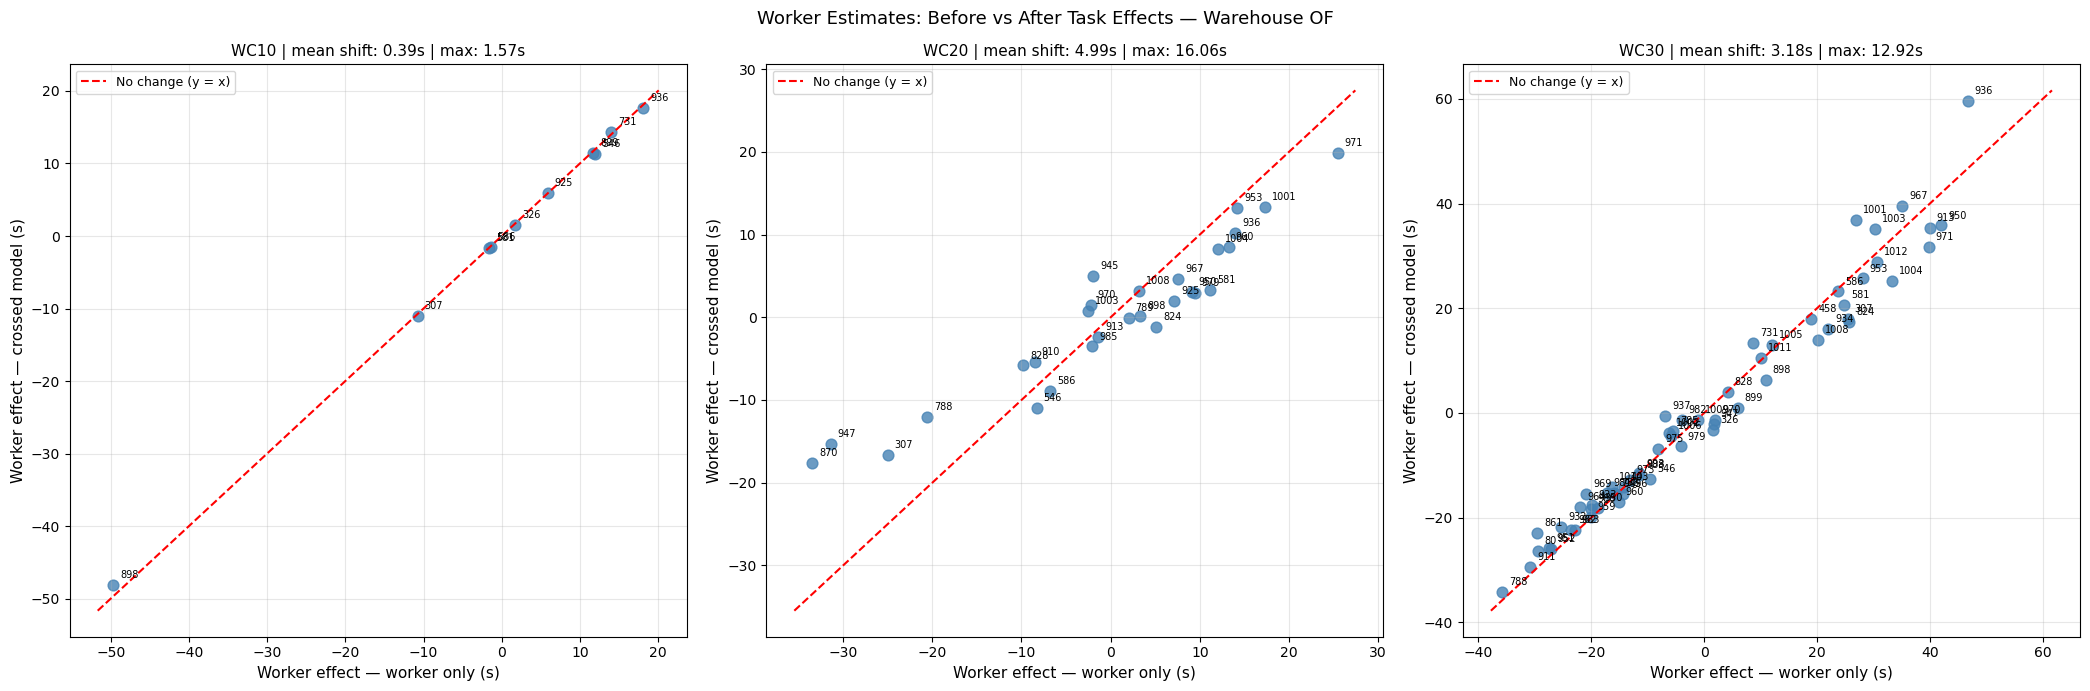

In [18]:
# Step 5: Worker estimates before vs after task effects — all workcodes
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, wc in zip(axes, WORKCODES):
    df_wc, _, _ = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_wc, _, _ = split_by_days(df_wc)
    train_wc["ProductID"] = train_wc["ProductID"].astype(str)

    # Worker-only estimates
    df_w = train_wc[["UserID", "Time_Delta_sec"]].dropna().copy()
    res_w = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_w, groups=df_w["UserID"]
    ).fit(reml=True, disp=False)
    worker_only = pd.DataFrame({
        "UserID":      list(res_w.random_effects.keys()),
        "worker_only": [float(v.iloc[0]) for v in res_w.random_effects.values()]
    })

    # Crossed estimates
    worker_crossed, _ = estimate_crossed_effects(train_wc)
    worker_crossed = worker_crossed.rename(columns={"worker_effect": "worker_crossed"})

    # Compare
    comp = worker_only.merge(worker_crossed, on="UserID", how="inner")
    comp["shift"]     = comp["worker_crossed"] - comp["worker_only"]
    comp["abs_shift"] = comp["shift"].abs()

    # Plot
    ax.scatter(comp["worker_only"], comp["worker_crossed"],
               s=60, alpha=0.8, color="steelblue")

    for _, row in comp.iterrows():
        ax.annotate(str(row["UserID"]),
                    (row["worker_only"], row["worker_crossed"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)

    lims = [
        min(comp["worker_only"].min(), comp["worker_crossed"].min()) - 2,
        max(comp["worker_only"].max(), comp["worker_crossed"].max()) + 2
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="No change (y = x)")
    ax.set_xlabel("Worker effect — worker only (s)", fontsize=11)
    ax.set_ylabel("Worker effect — crossed model (s)", fontsize=11)
    ax.set_title(f"WC{wc} | mean shift: {comp['abs_shift'].mean():.2f}s | "
                 f"max: {comp['abs_shift'].max():.2f}s", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"WC{wc}: {comp['UserID'].nunique()} workers | "
          f"mean abs shift: {comp['abs_shift'].mean():.2f}s | "
          f"max shift: {comp['abs_shift'].max():.2f}s | "
          f"correlation: {comp['worker_only'].corr(comp['worker_crossed']):.4f}")

plt.suptitle(f"Worker Estimates: Before vs After Task Effects — Warehouse {WAREHOUSE}",
             fontsize=13)
plt.tight_layout()
plt.show()

## Step 6: Actual vs Predicted — Best Model (WC20 & WC30)

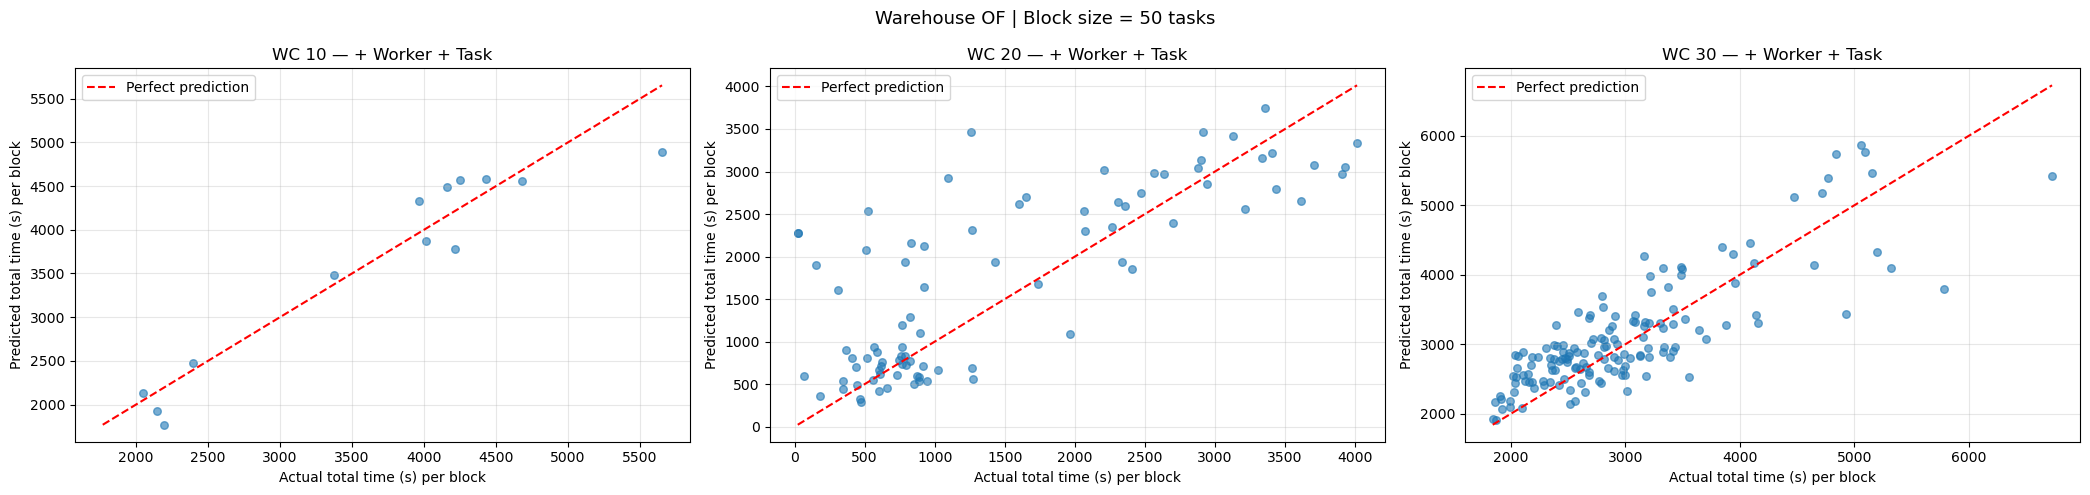

In [20]:
plot_model = "+ Worker + Task"
plot_df    = block_detail_df[block_detail_df["WorkCode"].isin(["10", "20", "30"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, wc in zip(axes, ["10", "20", "30"]):
    sub = plot_df[plot_df["WorkCode"] == wc]
    ax.scatter(sub["actual_time"], sub[plot_model], alpha=0.6, s=30)
    lims = [
        min(sub["actual_time"].min(), sub[plot_model].min()),
        max(sub["actual_time"].max(), sub[plot_model].max())
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual total time (s) per block")
    ax.set_ylabel("Predicted total time (s) per block")
    ax.set_title(f"WC {wc} — {plot_model}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Warehouse {WAREHOUSE} | Block size = {BLOCK_SIZE} tasks", fontsize=13)
plt.tight_layout()
plt.show()

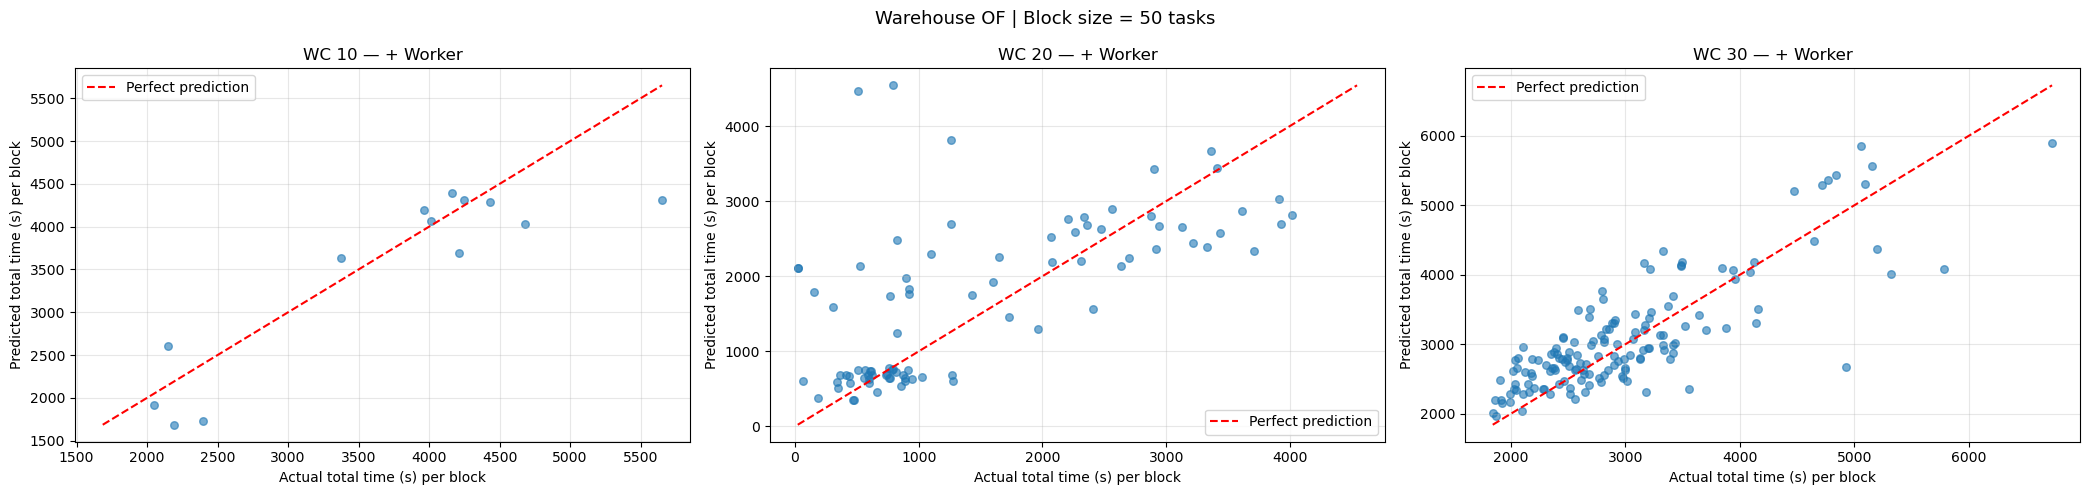

In [21]:
plot_model = "+ Worker"
plot_df    = block_detail_df[block_detail_df["WorkCode"].isin(["10", "20", "30"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, wc in zip(axes, ["10", "20", "30"]):
    sub = plot_df[plot_df["WorkCode"] == wc]
    ax.scatter(sub["actual_time"], sub[plot_model], alpha=0.6, s=30)
    lims = [
        min(sub["actual_time"].min(), sub[plot_model].min()),
        max(sub["actual_time"].max(), sub[plot_model].max())
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual total time (s) per block")
    ax.set_ylabel("Predicted total time (s) per block")
    ax.set_title(f"WC {wc} — {plot_model}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Warehouse {WAREHOUSE} | Block size = {BLOCK_SIZE} tasks", fontsize=13)
plt.tight_layout()
plt.show()